In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [3]:
BASE_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, "data", "blinkit_dataset.csv")
df = pd.read_csv(DATA_PATH)

## EDA

In [3]:
# EDA : check nulls, datatypes, rating distribution

df.head(5)



,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,NaN,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,NaN,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,NaN,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,NaN,On-Time


In [4]:
# dtypes + null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         13000 non-null  int64  
 1   product_name       13000 non-null  object 
 2   category           13000 non-null  object 
 3   brand              13000 non-null  object 
 4   price              13000 non-null  float64
 5   discount_pct       13000 non-null  int64  
 6   final_price        13000 non-null  float64
 7   rating             13000 non-null  float64
 8   num_reviews        13000 non-null  int64  
 9   delivery_time_min  13000 non-null  int64  
 10  city               13000 non-null  object 
 11  seller             13000 non-null  object 
 12  stock              13000 non-null  int64  
 13  sold_quantity      13000 non-null  int64  
 14  profit_margin_pct  13000 non-null  float64
 15  is_organic         13000 non-null  bool   
 16  packaging_type     130

In [5]:
# get stats - range, mean, std, min, max, count for numeric cols
df.describe()

,product_id,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,stock,sold_quantity,profit_margin_pct,weight_g,shelf_life_days,reorder_level,demand_index
count,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000
mean,6500.500000,267.303356,9.959231,240.735212,4.196931,255.000308,27.558769,110.140538,162.400077,22.652708,536.130769,397.555385,21.627769,43.380462
std,3752.921085,199.665148,8.575017,182.405552,0.475863,152.933513,7.139059,19.589137,132.742425,10.088389,406.997451,483.540218,3.928429,27.076935
min,1.000000,10.180000,0.000000,8.140000,2.500000,1.000000,10.000000,52.000000,0.000000,5.000000,100.000000,2.000000,10.000000,0.000000
25%,3250.750000,122.972500,0.000000,108.790000,3.900000,138.000000,23.000000,95.000000,54.000000,13.900000,250.000000,13.000000,19.000000,22.000000
50%,6500.500000,220.240000,10.000000,197.185000,4.200000,219.000000,27.000000,110.000000,120.000000,22.900000,400.000000,231.000000,22.000000,38.000000
75%,9750.250000,350.500000,15.000000,316.882500,4.500000,355.000000,32.000000,125.000000,253.000000,31.400000,750.000000,564.000000,25.000000,63.000000
max,13000.000000,999.930000,30.000000,998.920000,5.000000,1050.000000,56.000000,169.000000,720.000000,40.000000,2000.000000,1825.000000,33.000000,100.000000


In [ ]:
df.isnull().sum()

product_id              0
product_name            0
category                0
brand                   0
price                   0
discount_pct            0
final_price             0
rating                  0
num_reviews             0
delivery_time_min       0
city                    0
seller                  0
stock                   0
sold_quantity           0
profit_margin_pct       0
is_organic              0
packaging_type          0
weight_g                0
shelf_life_days         0
reorder_level           0
demand_index            0
date_added              0
expiry_date             0
offer_type           6544
delivery_status         0
dtype: int64

In [13]:
(df['rating'] >= 3.8).value_counts()

,count
rating,
True,10677
False,2323


<Axes: xlabel='rating', ylabel='Count'>

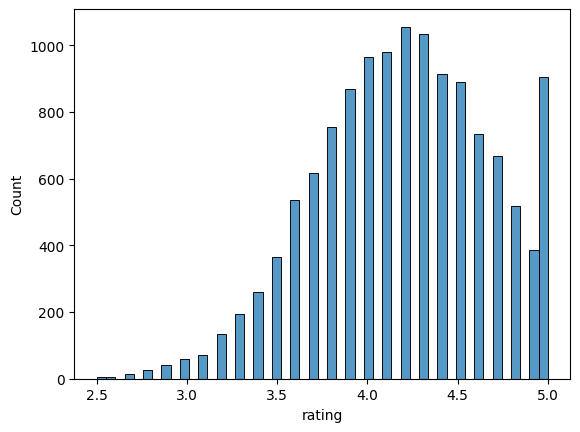

In [14]:
sns.histplot(df['rating'])

## Feature Engineering

In [4]:
df['date_added'].min(), df['date_added'].max()

('2023-10-28', '2025-10-27')

In [5]:
# handle the raw cols that need transformation

# days to expiry = expirydate - dateadded
# days since added = dateadded - 2023-01-01
# monthadded = extract month

df['date_added'] = pd.to_datetime(df['date_added'])
df['expiry_date'] = pd.to_datetime(df['expiry_date'])
REFERENCE_DATE = pd.Timestamp("2023-01-01")

df['days_to_expire'] = (df['expiry_date'] - df['date_added']).dt.days
df['days_since_added'] = (df['date_added'] - REFERENCE_DATE).dt.days
df['month_added'] = df['date_added'].dt.month


In [6]:
df['offer_type'] = df['offer_type'].fillna("No offer")

In [7]:
'''text category cols  :product_name, category, brand, city, seller
packaging_type, offer_type, 'delivery_status'

cols to drop/not select : product_name, delivery status
encode rest cols using label encoding
'''
from sklearn.preprocessing import LabelEncoder

label_encoder = {}
CAT_COLS = ["category", "brand", "city", "seller", "packaging_type", "offer_type"]

for col in CAT_COLS:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    label_encoder[col] = le

df["is_organic_enc"] = df['is_organic'].astype(int)


#interaction feature

df['price_per_gram'] = df['final_price'] / (df['weight_g']+1)
df['discount_amount'] = df['price'] - df['final_price']
df['freshness_score'] = df['days_to_expire']/(df['shelf_life_days']+1)



In [8]:
# Feature Selection

# FEAT_COL = [
#     #raw numbers
#     "price", "final_price", "profit_margin_pct", "weight_g", "shelf_life_days", "discount_pct",

#     #date-derived
#     "days_to_expire", "days_since_added", "month_added",

#     #interaction fetures
#     "price_per_gram", "discount_amount", "freshness_score",

#     #encoded categories
#     "category_enc", "brand_enc", "city_enc", "seller_enc", "packaging_type_enc", "offer_type_enc", "is_organic_enc"
# ]

FEAT_COL = [
    #raw numbers
    "price", "final_price", "profit_margin_pct", "weight_g", "shelf_life_days",

    #date-derived
    "days_since_added", "month_added",

    #interaction fetures
    "price_per_gram", "discount_amount", "freshness_score",

    #encoded categories
    "brand_enc", "city_enc", "seller_enc", "packaging_type_enc"
]




In [9]:
# Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

X = df[FEAT_COL]
Y = df['rating']


X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.20, random_state = 42, stratify=Y)

#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#linear regresion

lr = LinearRegression()
lr.fit(X_train_scaled, Y_train)

Y_pred = lr.predict(X_test_scaled)


#evaluation

rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
mae = mean_absolute_error(Y_test, Y_pred)

print("RMSE : ", rmse)
print("MAE : ", mae)



RMSE :  0.47604879161852587
MAE :  0.3868918786301058


## Classification as errors are high in regression model

In [10]:
Y = (df['rating'] >= 3.8).astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42,stratify=Y)



In [11]:
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

best_lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
best_lgbm.fit(X_train_scaled, Y_train)
print("Model trained!")
Y_pred_best = best_lgbm.predict(X_test_scaled)
print("Macro F1:", f1_score(Y_test, Y_pred_best, average='macro'))



Model trained!
Macro F1: 0.5058075696330634


/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = [
    ("Logistic Regression", LogisticRegression(class_weight='balanced', random_state=42)),
    ("Random Forest", RandomForestClassifier(class_weight='balanced', random_state=42)),
    ("LightGBM", LGBMClassifier(class_weight='balanced', random_state=42))
]

for name,model in models:
    model.fit(X_train_scaled,Y_train)

    Y_pred = model.predict(X_test_scaled)

    print(f"\n{name}")
    print("Accuracy :", accuracy_score(Y_test,Y_pred))
    print("Precision:", precision_score(Y_test, Y_pred))
    print("Recall   :", recall_score(Y_test, Y_pred))
    print(" F1 :", f1_score(Y_test, Y_pred))
    print("Macro F1 : ", f1_score(Y_test,Y_pred, average='macro'))





ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
}

lgbm = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)

search = RandomizedSearchCV(
    lgbm,
    param_grid,
    n_iter=20,
    cv=5,
    scoring='f1_macro',
    random_state=42
)

search.fit(X_train_scaled,Y_train)

print("Best params:", search.best_params_)
print("Best Macro F1:", search.best_score_)


/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does n

Best params: {'num_leaves': 31, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}
Best Macro F1: 0.5101970780363597


In [16]:
best_lgbm = LGBMClassifier(
    **search.best_params_,
    class_weight='balanced',
    random_state=42,
    verbose = -1
)
best_lgbm.fit(X_train_scaled, Y_train)
Y_pred_best = best_lgbm.predict(X_test_scaled)

print("Macro F1:", f1_score(Y_test, Y_pred_best, average='macro'))


Macro F1: 0.5058075696330634


/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [19]:
from sklearn.model_selection import GridSearchCV

search_grid = GridSearchCV(
    lgbm,
    param_grid,
    cv=5,
    scoring='f1_macro',

)

search_grid.fit(X_train_scaled, Y_train)

print("Best params:", search_grid.best_params_)
print("Best Macro F1:", search_grid.best_score_)


/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does n

Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'num_leaves': 31}
Best Macro F1: 0.5101970780363597


/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [20]:
Y_pred_best = search_grid.best_estimator_.predict(X_test_scaled)

print("Accuracy :", accuracy_score(Y_test, Y_pred_best))
print("Precision:", precision_score(Y_test, Y_pred_best))
print("Recall   :", recall_score(Y_test, Y_pred_best))
print("Macro F1 :", f1_score(Y_test, Y_pred_best, average='macro'))
print(" F1 :", f1_score(Y_test, Y_pred_best))



Accuracy : 0.688076923076923
Precision: 0.8238747553816047
Recall   : 0.7887587822014052
Macro F1 : 0.5058075696330634
 F1 : 0.8059344340751375


/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [21]:
param_grid_lr = {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "liblinear"]}
lr_tune = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
search_lr = GridSearchCV(lr_tune, param_grid_lr, cv=5, scoring="f1_macro", n_jobs=-1)
search_lr.fit(X_train_scaled, Y_train)
Y_pred_lr = search_lr.best_estimator_.predict(X_test_scaled)
print("Best params:", search_lr.best_params_)
print("Accuracy :", round(accuracy_score(Y_test, Y_pred_lr), 4))
print("Precision:", round(precision_score(Y_test, Y_pred_lr), 4))
print("Recall   :", round(recall_score(Y_test, Y_pred_lr), 4))
print("F1       :", round(f1_score(Y_test, Y_pred_lr), 4))
print("Macro F1 :", round(f1_score(Y_test, Y_pred_lr, average="macro"), 4))

Best params: {'C': 0.1, 'solver': 'liblinear'}
Accuracy : 0.4942
Precision: 0.8228
Recall   : 0.4895
F1       : 0.6138
Macro F1 : 0.4406


In [22]:
param_grid_rf = {"n_estimators": [100, 200], "max_depth": [6, 10, None], "min_samples_split": [2, 5]}
rf_tune = RandomForestClassifier(class_weight="balanced", random_state=42)
search_rf = GridSearchCV(rf_tune, param_grid_rf, cv=5, scoring="f1_macro", n_jobs=-1)
search_rf.fit(X_train_scaled, Y_train)
Y_pred_rf = search_rf.best_estimator_.predict(X_test_scaled)
print("Best params:", search_rf.best_params_)
print("Accuracy :", round(accuracy_score(Y_test, Y_pred_rf), 4))
print("Precision:", round(precision_score(Y_test, Y_pred_rf), 4))
print("Recall   :", round(recall_score(Y_test, Y_pred_rf), 4))
print("F1       :", round(f1_score(Y_test, Y_pred_rf), 4))
print("Macro F1 :", round(f1_score(Y_test, Y_pred_rf, average="macro"), 4))

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy : 0.6873
Precision: 0.8181
Recall   : 0.7963
F1       : 0.807
Macro F1 : 0.4917


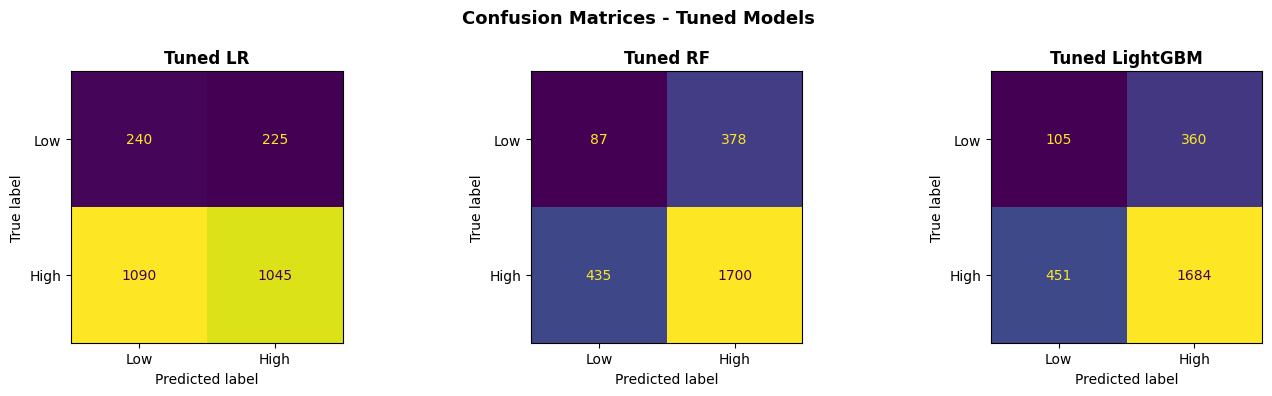

In [24]:
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the folder in Colab's filesystem
output_dir = "../deck/ml"
os.makedirs(output_dir, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, y_pred) in zip(axes, [
    ("Tuned LR", Y_pred_lr),
    ("Tuned RF", Y_pred_rf),
    ("Tuned LightGBM", Y_pred_best),
]):
    cm = confusion_matrix(Y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Low", "High"]).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontweight="bold")
plt.suptitle("Confusion Matrices - Tuned Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confusion_matrices_pre.png"), dpi=150, bbox_inches="tight")
plt.show()

         Model  Accuracy  Precision  Recall     F1  Macro F1
      Tuned LR    0.4942     0.8228  0.4895 0.6138    0.4406
      Tuned RF    0.6873     0.8181  0.7963 0.8070    0.4917
Tuned LightGBM    0.6881     0.8239  0.7888 0.8059    0.5058


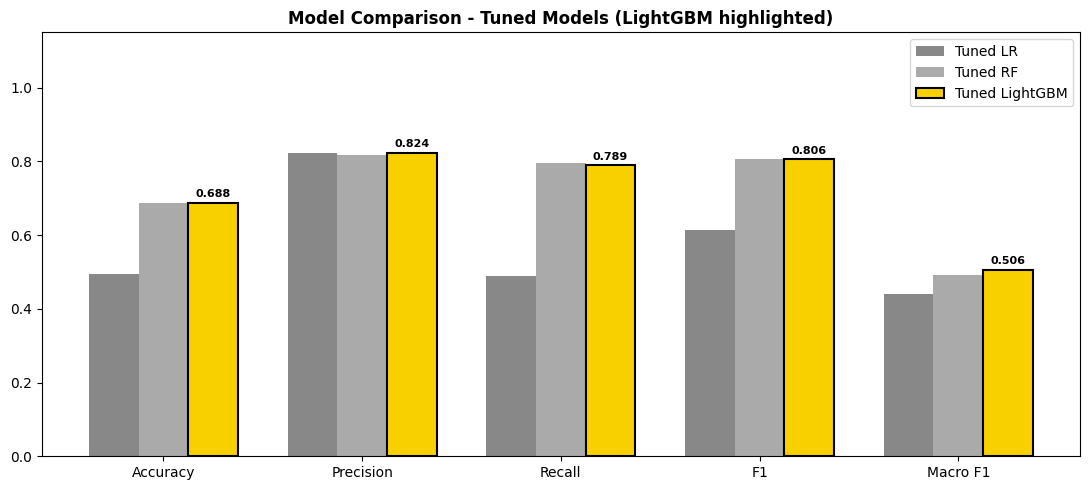

In [25]:
import pandas as pd
import numpy as np

results = pd.DataFrame({
    "Model": ["Tuned LR", "Tuned RF", "Tuned LightGBM"],
    "Accuracy":  [round(accuracy_score(Y_test, Y_pred_lr), 4),
                  round(accuracy_score(Y_test, Y_pred_rf), 4),
                  round(accuracy_score(Y_test, Y_pred_best), 4)],
    "Precision": [round(precision_score(Y_test, Y_pred_lr), 4),
                  round(precision_score(Y_test, Y_pred_rf), 4),
                  round(precision_score(Y_test, Y_pred_best), 4)],
    "Recall":    [round(recall_score(Y_test, Y_pred_lr), 4),
                  round(recall_score(Y_test, Y_pred_rf), 4),
                  round(recall_score(Y_test, Y_pred_best), 4)],
    "F1":        [round(f1_score(Y_test, Y_pred_lr), 4),
                  round(f1_score(Y_test, Y_pred_rf), 4),
                  round(f1_score(Y_test, Y_pred_best), 4)],
    "Macro F1":  [round(f1_score(Y_test, Y_pred_lr, average="macro"), 4),
                  round(f1_score(Y_test, Y_pred_rf, average="macro"), 4),
                  round(f1_score(Y_test, Y_pred_best, average="macro"), 4)],
})
print(results.to_string(index=False))

metrics = ["Accuracy", "Precision", "Recall", "F1", "Macro F1"]
x = np.arange(len(metrics))
width = 0.25
colors = ["#888888", "#AAAAAA", "#F8D000"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics], width,
                  label=row["Model"], color=colors[i],
                  edgecolor="black" if row["Model"] == "Tuned LightGBM" else "none",
                  linewidth=1.5)
    if row["Model"] == "Tuned LightGBM":
        for bar in bars:
            ax.annotate(f'{bar.get_height():.3f}',
                        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        xytext=(0, 4), textcoords="offset points",
                        ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_title("Model Comparison - Tuned Models (LightGBM highlighted)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../deck/ml/model_comparison_pre.png", dpi=150, bbox_inches="tight")
plt.show()

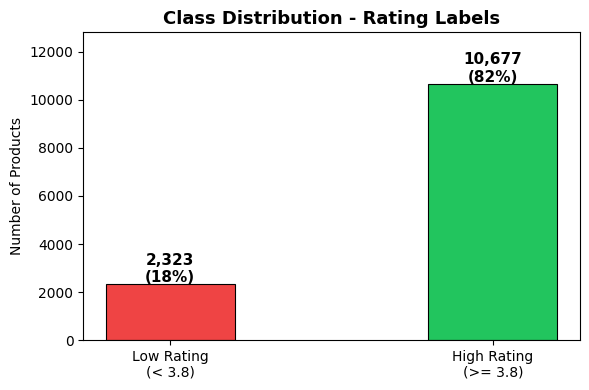

In [27]:
class_counts = Y.value_counts().sort_index()
labels = ["Low Rating\n(< 3.8)", "High Rating\n(>= 3.8)"]
bar_colors = ["#EF4444", "#22C55E"]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, class_counts.values, color=bar_colors, width=0.4, edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, class_counts.values):
    pct = val / len(Y) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f"{val:,}\n({pct:.0f}%)", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Class Distribution - Rating Labels", fontweight="bold", fontsize=13)
ax.set_ylabel("Number of Products")
ax.set_ylim(0, max(class_counts.values) * 1.2)
plt.tight_layout()
plt.savefig("../deck/ml/class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

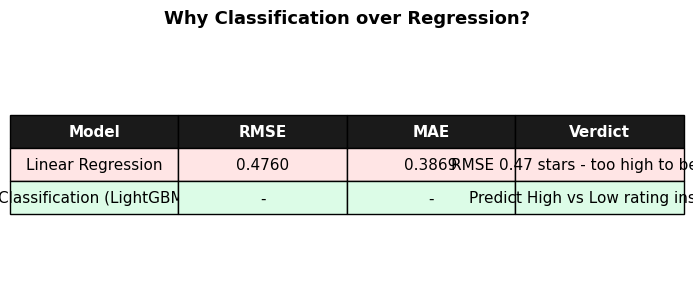

In [28]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.axis("off")
data = [
    ["Model", "RMSE", "MAE", "Verdict"],
    ["Linear Regression", "0.4760", "0.3869", "RMSE 0.47 stars - too high to be useful"],
    ["Classification (LightGBM)", "-", "-", "Predict High vs Low rating instead"],
]
table = ax.table(cellText=data[1:], colLabels=data[0], cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#1A1A1A")
        cell.set_text_props(color="white", fontweight="bold")
    elif row == 1:
        cell.set_facecolor("#FFE5E5")
    elif row == 2:
        cell.set_facecolor("#DCFCE7")
ax.set_title("Why Classification over Regression?", fontweight="bold", fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("../deck/ml/regression_vs_classification.png", dpi=150, bbox_inches="tight")
plt.show()

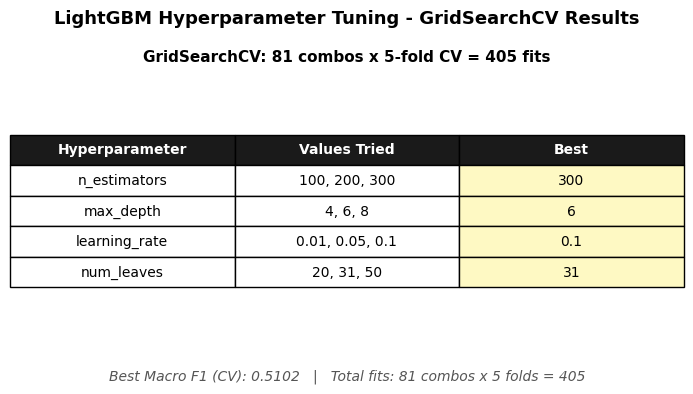

In [29]:
import os
fig, ax = plt.subplots(figsize=(7, 4))
ax.axis("off")
grid_data = [
    ["Hyperparameter", "Values Tried", "Best"],
    ["n_estimators",   "100, 200, 300", str(search_grid.best_params_["n_estimators"])],
    ["max_depth",      "4, 6, 8",       str(search_grid.best_params_["max_depth"])],
    ["learning_rate",  "0.01, 0.05, 0.1", str(search_grid.best_params_["learning_rate"])],
    ["num_leaves",     "20, 31, 50",    str(search_grid.best_params_["num_leaves"])],
]
table = ax.table(cellText=grid_data[1:], colLabels=grid_data[0], cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#1A1A1A")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 2 and row > 0:
        cell.set_facecolor("#FEF9C3")
ax.set_title("GridSearchCV: 81 combos x 5-fold CV = 405 fits", fontweight="bold", fontsize=11)
ax.text(0.5, -0.1,
        f"Best Macro F1 (CV): {search_grid.best_score_:.4f}   |   Total fits: 81 combos x 5 folds = 405",
        ha="center", transform=ax.transAxes, fontsize=10, style="italic", color="#555555")
plt.suptitle("LightGBM Hyperparameter Tuning - GridSearchCV Results", fontsize=13, fontweight="bold")
plt.tight_layout()
# os.makedirs("../deck/ml", exist_ok=True)
plt.savefig("../deck/ml/hyperparameter_tuning_pre.png", dpi=150, bbox_inches="tight")
plt.show()

/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


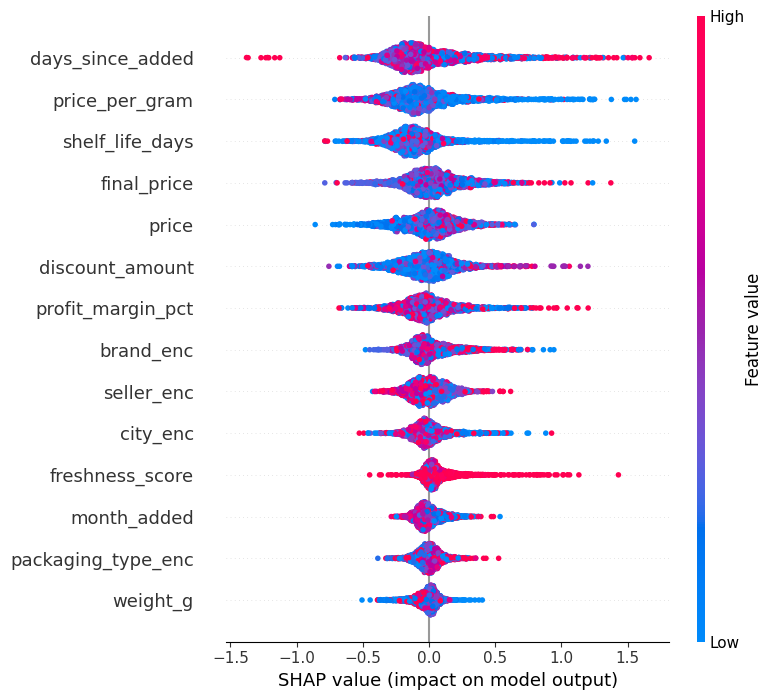

In [30]:
import shap

explainer = shap.TreeExplainer(search_grid.best_estimator_)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=FEAT_COL, show=False)
plt.savefig("../deck/ml/shap_beeswarm_pre.png", dpi=150, bbox_inches="tight")
plt.show()

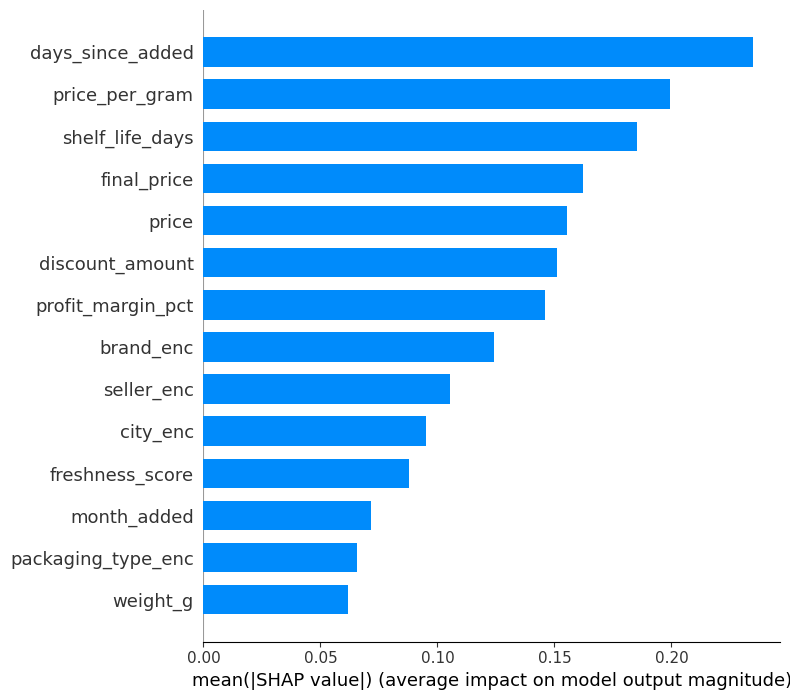

In [32]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=FEAT_COL, plot_type="bar", show=False)
plt.savefig("../deck/ml/shap_bar_pre.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("blinkInsighT")

with mlflow.start_run():
    mlflow.sklearn.log_model(best_lgbm, name="lgbm_pre_launch")
    mlflow.log_metric("f1_macro", f1_score(Y_test, best_lgbm.predict(X_test_scaled), average="macro"))
    mlflow.log_metric("accuracy", accuracy_score(Y_test, best_lgbm.predict(X_test_scaled)))
    print("Model saved to MLflow.")


2026/06/10 20:52:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model saved to MLflow.


/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
